# Determinant and Inverse

**Goal:** Understand what determinant means, implement it from scratch.

**Reference:** Mathematics for ML - Chapter 2.3, 2.4


## What is a Determinant?

The determinant of a square matrix $A$ is a scalar that tells us how the matrix **scales area (2D) or volume (3D)** when applied as a linear transformation.

$$A = \begin{bmatrix} a & b \\ c & d \end{bmatrix} \quad \Rightarrow \quad \det(A) = ad - bc$$

**Geometric meaning:**
- $\det(A) > 0$: transformation preserves orientation
- $\det(A) < 0$: transformation flips orientation
- $\det(A) = 0$: transformation collapses space (matrix is **singular**, no inverse exists)
- $|\det(A)|$: scaling factor of area/volume

**Key property:** $\det(AB) = \det(A) \cdot \det(B)$


In [43]:
import numpy as np 
import matplotlib.pyplot as plt


## 2x2 Determinant

For $A = \begin{bmatrix} a & b \\ c & d \end{bmatrix}$:

$$\det(A) = ad - bc$$

In [44]:
def det_2x2(A):
  assert len(A) ==2 and len(A[0])
  a , b = A[0]
  c , d = A[1]
  return a * d - b * c

# test
A = [[1,4],[3,6]]
print("My:   ", det_2x2(A))
print("Numpy:" , np.linalg.det(A))

My:    -6
Numpy: -6.0


## 3x3 Determinant

For a 3x3 matrix, we expand along the first row:

$$A = \begin{bmatrix} a & b & c \\ d & e & f \\ g & h & i \end{bmatrix}$$

$$\det(A) = a(ei - fh) - b(di - fg) + c(dh - eg)$$

Each term is a **cofactor** — a 2x2 determinant times a sign.

Sign pattern:
$$\begin{bmatrix} + & - & + \\ - & + & - \\ + & - & + \end{bmatrix}$$

In [45]:
def det_3x3(A):
  assert len(A) == 3 and len(A[0]) ==3
  a , b , c = A[0]
  d , e , f = A[1]
  g , h , i = A[2]
  return a * (e * i - f * h) - b * (d * i - f * g) + c * (d * h - e * g)

# test
A = [[1, 2, 3], [4, 7, 6], [7, 3, 10]]
print("My:   ", det_3x3(A))
print("Numpy:", np.linalg.det(A))


My:    -55
Numpy: -55.000000000000014


## General n×n Determinant

For any size, we can use **cofactor expansion** along any row:

$$\det(A) = \sum_{j=1}^{n} (-1)^{1+j} a_{1j} \cdot M_{1j}$$

where $M_{1j}$ is the **minor** — the determinant of the matrix with row 1 and column j removed.

Sign alternates: $(-1)^{i+j}$.

In [46]:
def det_recursive(A):
  n = len(A)
  assert all(len(row) == n for row in A)

  if n ==1:
    return A[0][0]
  
  if n == 2 :
    return A[0][0] * A[1][1] - A[0][1] * A[1][0]
  
  # Recursive case: cofactor expansion along first row
  total = 0 
  for j in range(n):
    minor = [row[:j] + row[j+1: ] for row in A[1:]]
    sign = (-1) ** j
    total += sign * A[0][j] * det_recursive(minor)
  return total

# test
for n in [2,3,4,5]:
  A = [[i + j * 2  for j in range(n)] for i in range(n)]
  print(f"n={n}: My={det_recursive(A):.4f}  NumPy={np.linalg.det(A):.4f}")


n=2: My=-2.0000  NumPy=-2.0000
n=3: My=0.0000  NumPy=0.0000
n=4: My=0.0000  NumPy=0.0000
n=5: My=0.0000  NumPy=0.0000


## Visualizing the Determinant

A matrix transforms the unit square into a parallelogram.

The **area** of that parallelogram equals $|\det(A)|$.

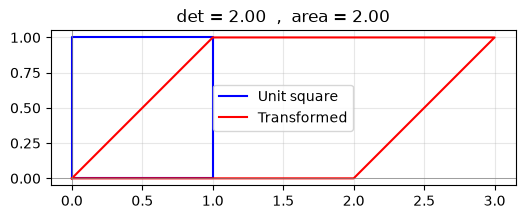

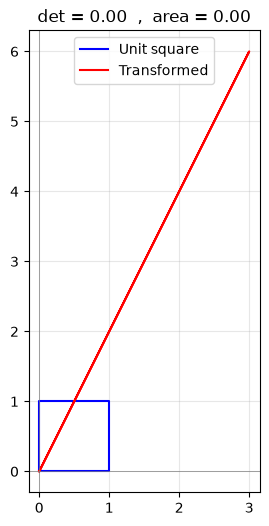

In [47]:
def plot_transformation(A):
  square = np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]])
  transformed = (np.array(A) @ square.T).T

  fig , ax = plt.subplots(figsize =(6,6))
  ax.plot(square[:, 0], square[:, 1], 'b-', label='Unit square')
  ax.plot(transformed[:, 0], transformed[:, 1], 'r-', label='Transformed')

  det = np.linalg.det(A)
  ax.set_title(f"det = {det:.2f}  ,  area = {abs(det):.2f}")

  ax.axhline(0, color='gray' , linewidth=0.5)
  ax.axvline(0, color='gray', linewidth=0.5)

  ax.grid(True, alpha=0.3)
  ax.legend()

  ax.set_aspect('equal')

  plt.show()
 
plot_transformation([[2, 1], [0, 1]])   
plot_transformation([[1, 2], [2, 4]])  

## Matrix Inverse

The inverse $A^{-1}$ satisfies:

$$A \cdot A^{-1} = A^{-1} \cdot A = I$$

**When does it exist?** Only when $\det(A) \neq 0$. If $\det(A) = 0$, matrix is **singular** and has no inverse.

For a 2x2 matrix:

$$A^{-1} = \frac{1}{\det(A)} \begin{bmatrix} d & -b \\ -c & a \end{bmatrix}$$

In [52]:
def inv_2x2(A):
  det = det_2x2(A)
  if det == 0:
    raise ValueError("Matrix is singular, no inverse exists")
  a, b = A[0]
  c, d = A[1]
  return [[d / det, -b / det],
          [-c / det, a / det]]


# test 
A = [[4, 8], [5, 6]]
A_inv = inv_2x2(A)
print("My inverse:   ", A_inv)
print("NumPy inverse:" , np.linalg.inv(A).tolist())

# Verify: A @ A_inv = I
identity_check = np.array(A) @ np.array(A_inv)
print("\nA @ A_inv =")
print(identity_check)


My inverse:    [[-0.375, 0.5], [0.3125, -0.25]]
NumPy inverse: [[-0.3750000000000001, 0.5000000000000001], [0.31250000000000006, -0.25000000000000006]]

A @ A_inv =
[[1. 0.]
 [0. 1.]]


## Key Takeaways

- $\det(A)$ measures how much $A$ scales area/volume
- $\det(A) = 0$ ⟺ matrix is singular (no inverse, columns are linearly dependent)
- $\det(AB) = \det(A) \det(B)$
- Inverse only exists when $\det(A) \neq 0$
- For 2x2: $\det = ad - bc$ and $A^{-1} = \frac{1}{\det}\begin{bmatrix} d & -b \\ -c & a \end{bmatrix}$

## Connection to ML

- **Singular matrices in ML**: when features are linearly dependent, $X^T X$ becomes singular → can't solve normal equation directly → need regularization (Ridge)
- **Determinant in probability**: change of variables for PDFs (Jacobian determinant)
- **Numerical stability**: directly computing inverse is unstable; we use LU decomposition or pseudo-inverse in practice